# 市场数据分析 - 历史波动率与收益率计算

## 分析目标
基于上市公司历史交易数据，计算真实的统计指标：
- 不同窗口的波动率（30/60/120/180日）
- 不同窗口的平均股价
- 历史收益率（年化）
- 价格统计特征
- 导出数据供其他模块使用

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import tushare as ts
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json
import os

# 配置中文字体
from utils.font_manager import get_font_prop
font_prop = get_font_prop()

%matplotlib inline
sns.set_style('whitegrid')

print('✅ 市场数据分析模块加载成功')

✅ 使用系统字体: /System/Library/Fonts/STHeiti Medium.ttc
✅ 市场数据分析模块加载成功


## 1. 参数设置

In [ ]:
# ============================================================
# 股票配置 - 修改这里来分析不同的股票
# ============================================================

# 检查当前工作目录
import os
print(f"当前工作目录: {os.getcwd()}")

# 方式1: 直接配置（使用当前日期）
STOCK_CONFIG = {
    'code': '300735.SZ',     # 光弘科技
    'name': '光弘科技',
    'analysis_date': datetime.now().strftime('%Y-%m-%d'),  # 使用当前日期
}

# 方式2: 从JSON文件加载（尝试多个可能路径）
possible_params_paths = [
    '../data/300735_SZ_placement_params.json',
    '../300735_SZ_placement_params.json',
    '../../data/300735_SZ_placement_params.json',
    'data/300735_SZ_placement_params.json',
    './data/300735_SZ_placement_params.json',
]

params_file = None
print("\n检查参数文件路径:")
for path in possible_params_paths:
    exists = os.path.exists(path)
    if exists:
        params_file = path
        print(f"  ✅ {path}")
        break
    else:
        print(f"  ❌ {path}")

if params_file:
    with open(params_file, 'r', encoding='utf-8') as f:
        params = json.load(f)
    print(f"\n✅ 已加载参数文件: {params_file}")
    print(f"   股票代码: {params.get('stock_code', STOCK_CONFIG['code'])}")
else:
    print(f"\n⚠️ 参数文件不存在，使用手动配置")
    print(f"   请检查文件路径或手动配置STOCK_CONFIG")

# 历史数据参数
HISTORY_PARAMS = {
    'lookback_days': 500,          # 获取过去500天的历史数据
    'windows': [30, 60, 120, 180], # 计算窗口
}

print('='*70)
print(f'📊 股票: {STOCK_CONFIG["name"]} ({STOCK_CONFIG["code"]})')
print(f'📅 分析日期: {STOCK_CONFIG.get("analysis_date", "最新交易日")}（使用当前日期回溯）')
print('='*70)

## 2. 获取历史行情数据

In [ ]:
# 初始化Tushare API（从环境变量获取Token）
ts_token = os.environ.get('TUSHARE_TOKEN', '')

if not ts_token:
    print("⚠️ 请先设置 Tushare Token:")
    print("   export TUSHARE_TOKEN='your_token_here'")
    print("   或在当前notebook中设置环境变量")
    # 创建一个空的pro对象，避免后续代码报错
    pro = None
else:
    ts.set_token(ts_token)
    pro = ts.pro_api()
    print(f"✅ Tushare API 初始化成功")

# 获取历史行情数据
end_date = datetime.now().strftime('%Y%m%d')
start_date = (datetime.now() - timedelta(days=HISTORY_PARAMS['lookback_days'])).strftime('%Y%m%d')

print(f"获取 {STOCK_CONFIG['name']} ({STOCK_CONFIG['code']}) 的历史数据...")
print(f"时间范围: {start_date} - {end_date}")

if pro is None:
    print("❌ 无法获取数据：Tushare Token 未设置")
    df_daily = pd.DataFrame()  # 创建空DataFrame避免后续错误
else:
    try:
        df_daily = pro.daily(ts_code=STOCK_CONFIG['code'], start_date=start_date, end_date=end_date)
        
        if df_daily.empty:
            print(f"⚠️ 未获取到数据，请检查股票代码: {STOCK_CONFIG['code']}")
        else:
            # 按日期升序排列
            df_daily = df_daily.sort_values('trade_date').reset_index(drop=True)
            print(f"✅ 成功获取 {len(df_daily)} 条交易数据")
            print(f"   数据范围: {df_daily['trade_date'].iloc[0]} - {df_daily['trade_date'].iloc[-1]}")
            print(f"   最新收盘价: {df_daily['close'].iloc[-1]:.2f} 元")
    except Exception as e:
        print(f"❌ 获取数据失败: {e}")
        df_daily = pd.DataFrame()  # 创建空DataFrame避免后续错误

In [ ]:
def calculate_rolling_volatility(df, window, annualize=True):
    """
    计算滚动波动率
    
    参数:
        df: 包含pct_chg列的DataFrame（pct_chg为百分比形式，如2.5表示2.5%）
        window: 窗口大小（交易日）
        annualize: 是否年化
    
    返回:
        波动率序列和统计值（小数形式，如0.23表示23%）
    """
    # Tushare的pct_chg是百分比形式（如2.5表示2.5%），需要先转换为小数
    pct_decimal = df['pct_chg'] / 100.0
    
    # 计算滚动标准差
    rolling_std = pct_decimal.rolling(window=window).std()
    
    # 年化波动率 (假设一年252个交易日)
    if annualize:
        rolling_vol = rolling_std * np.sqrt(252)
    else:
        rolling_vol = rolling_std
    
    # 返回最新值和平均值
    return {
        'latest': rolling_vol.iloc[-1],  # 最新波动率
        'mean': rolling_vol.mean(),      # 平均波动率
        'median': rolling_vol.median(),   # 中位数波动率
        'max': rolling_vol.max(),        # 最大波动率
        'min': rolling_vol.min(),        # 最小波动率
        'series': rolling_vol             # 完整序列（用于绘图）
    }

if not df_daily.empty:
    volatility_analysis = {}
    
    print('\n=== 不同窗口波动率分析 ===')
    print(f"{'窗口':<10} {'最新波动率':<15} {'平均波动率':<15} {'中位数':<15} {'最大':<15} {'最小':<15}")
    print('-'*80)
    
    for window in HISTORY_PARAMS['windows']:
        vol_stats = calculate_rolling_volatility(df_daily, window)
        volatility_analysis[f'{window}日'] = vol_stats
        
        print(f"{window}日{'':>5} {vol_stats['latest']*100:>7.2f}%       "
              f"{vol_stats['mean']*100:>7.2f}%       "
              f"{vol_stats['median']*100:>7.2f}%       "
              f"{vol_stats['max']*100:>7.2f}%       "
              f"{vol_stats['min']*100:>7.2f}%")

## 3. 计算基础统计指标

In [4]:
if not df_daily.empty:
    # 基础统计
    basic_stats = {
        '股票代码': STOCK_CONFIG['code'],
        '股票名称': STOCK_CONFIG['name'],
        '数据起始日': df_daily['trade_date'].iloc[0],
        '数据截止日': df_daily['trade_date'].iloc[-1],
        '交易日数量': len(df_daily),
        '最新收盘价': df_daily['close'].iloc[-1],
        '期间最高价': df_daily['high'].max(),
        '期间最低价': df_daily['low'].min(),
        '平均收盘价': df_daily['close'].mean(),
        '收盘价中位数': df_daily['close'].median(),
        '收盘价标准差': df_daily['close'].std(),
    }
    
    print('\n=== 基础统计 ===')
    for key, value in basic_stats.items():
        if isinstance(value, float):
            print(f"{key:<15}: {value:.2f}")
        else:
            print(f"{key:<15}: {value}")


=== 基础统计 ===
股票代码           : 300735.SZ
股票名称           : 光弘科技
数据起始日          : 20221018
数据截止日          : 20240301
交易日数量          : 334
最新收盘价          : 22.46
期间最高价          : 34.99
期间最低价          : 8.81
平均收盘价          : 13.99
收盘价中位数         : 11.09
收盘价标准差         : 5.79


## 5. 计算不同窗口的平均股价

In [6]:
if not df_daily.empty:
    price_analysis = {}
    
    print('\n=== 不同窗口平均股价分析 ===')
    print(f"{'窗口':<10} {'最新均价':<15} {'期间最高':<15} {'期间最低':<15} {'标准差':<15}")
    print('-'*65)
    
    for window in HISTORY_PARAMS['windows']:
        # 计算滚动平均
        rolling_mean = df_daily['close'].rolling(window=window).mean()
        recent_prices = df_daily['close'].iloc[-window:]  # 最近N天的价格
        
        price_stats = {
            'latest_ma': rolling_mean.iloc[-1],      # 最新移动平均
            'recent_mean': recent_prices.mean(),     # 最近N天简单平均
            'recent_max': recent_prices.max(),       # 最近N天最高价
            'recent_min': recent_prices.min(),       # 最近N天最低价
            'recent_std': recent_prices.std(),       # 最近N天标准差
            'series': rolling_mean                   # 完整序列
        }
        
        price_analysis[f'{window}日'] = price_stats
        
        print(f"{window}日{'':>5} {price_stats['latest_ma']:>8.2f}元      "
              f"{price_stats['recent_max']:>8.2f}元      "
              f"{price_stats['recent_min']:>8.2f}元      "
              f"{price_stats['recent_std']:>8.2f}元")


=== 不同窗口平均股价分析 ===
窗口         最新均价            期间最高            期间最低            标准差            
-----------------------------------------------------------------
30日         17.86元         22.46元         14.40元          1.80元
60日         20.23元         24.80元         14.40元          2.86元
120日         20.38元         33.11元         11.16元          5.31元
180日         17.15元         33.11元          9.93元          6.32元


## 6. 计算历史收益率（漂移率）

In [7]:
if not df_daily.empty:
    returns_analysis = {}
    
    print('\n=== 历史收益率分析 ===')
    
    # 整体收益率
    total_return = (df_daily['close'].iloc[-1] / df_daily['close'].iloc[0] - 1)
    days = len(df_daily)
    years = days / 252
    annualized_return = (1 + total_return) ** (1 / years) - 1
    
    print(f"\n整体表现:")
    print(f"  期间收益率: {total_return*100:.2f}%")
    print(f"  年化收益率: {annualized_return*100:.2f}%")
    
    # 不同窗口的收益率
    print(f"\n{'窗口':<10} {'期间收益率':<20} {'年化收益率':<20} {'胜率':<15}")
    print('-'*65)
    
    for window in HISTORY_PARAMS['windows']:
        recent_df = df_daily.iloc[-window:]
        
        # 期间收益率
        window_return = (recent_df['close'].iloc[-1] / recent_df['close'].iloc[0] - 1)
        
        # 年化收益率
        window_years = window / 252
        window_annualized = (1 + window_return) ** (1 / window_years) - 1
        
        # 胜率（上涨天数占比）
        win_rate = (recent_df['pct_chg'] > 0).sum() / len(recent_df)
        
        returns_analysis[f'{window}日'] = {
            'total_return': window_return,
            'annualized_return': window_annualized,
            'win_rate': win_rate
        }
        
        print(f"{window}日{'':>5} {window_return*100:>8.2f}%           "
              f"{window_annualized*100:>8.2f}%           "
              f"{win_rate*100:>8.1f}%")


=== 历史收益率分析 ===

整体表现:
  期间收益率: 117.64%
  年化收益率: 79.81%

窗口         期间收益率                年化收益率                胜率             
-----------------------------------------------------------------
30日         13.15%             182.26%               53.3%
60日         -7.53%             -28.03%               43.3%
120日         99.47%             326.31%               48.3%
180日        104.93%             173.05%               48.3%


## 7. 可视化分析

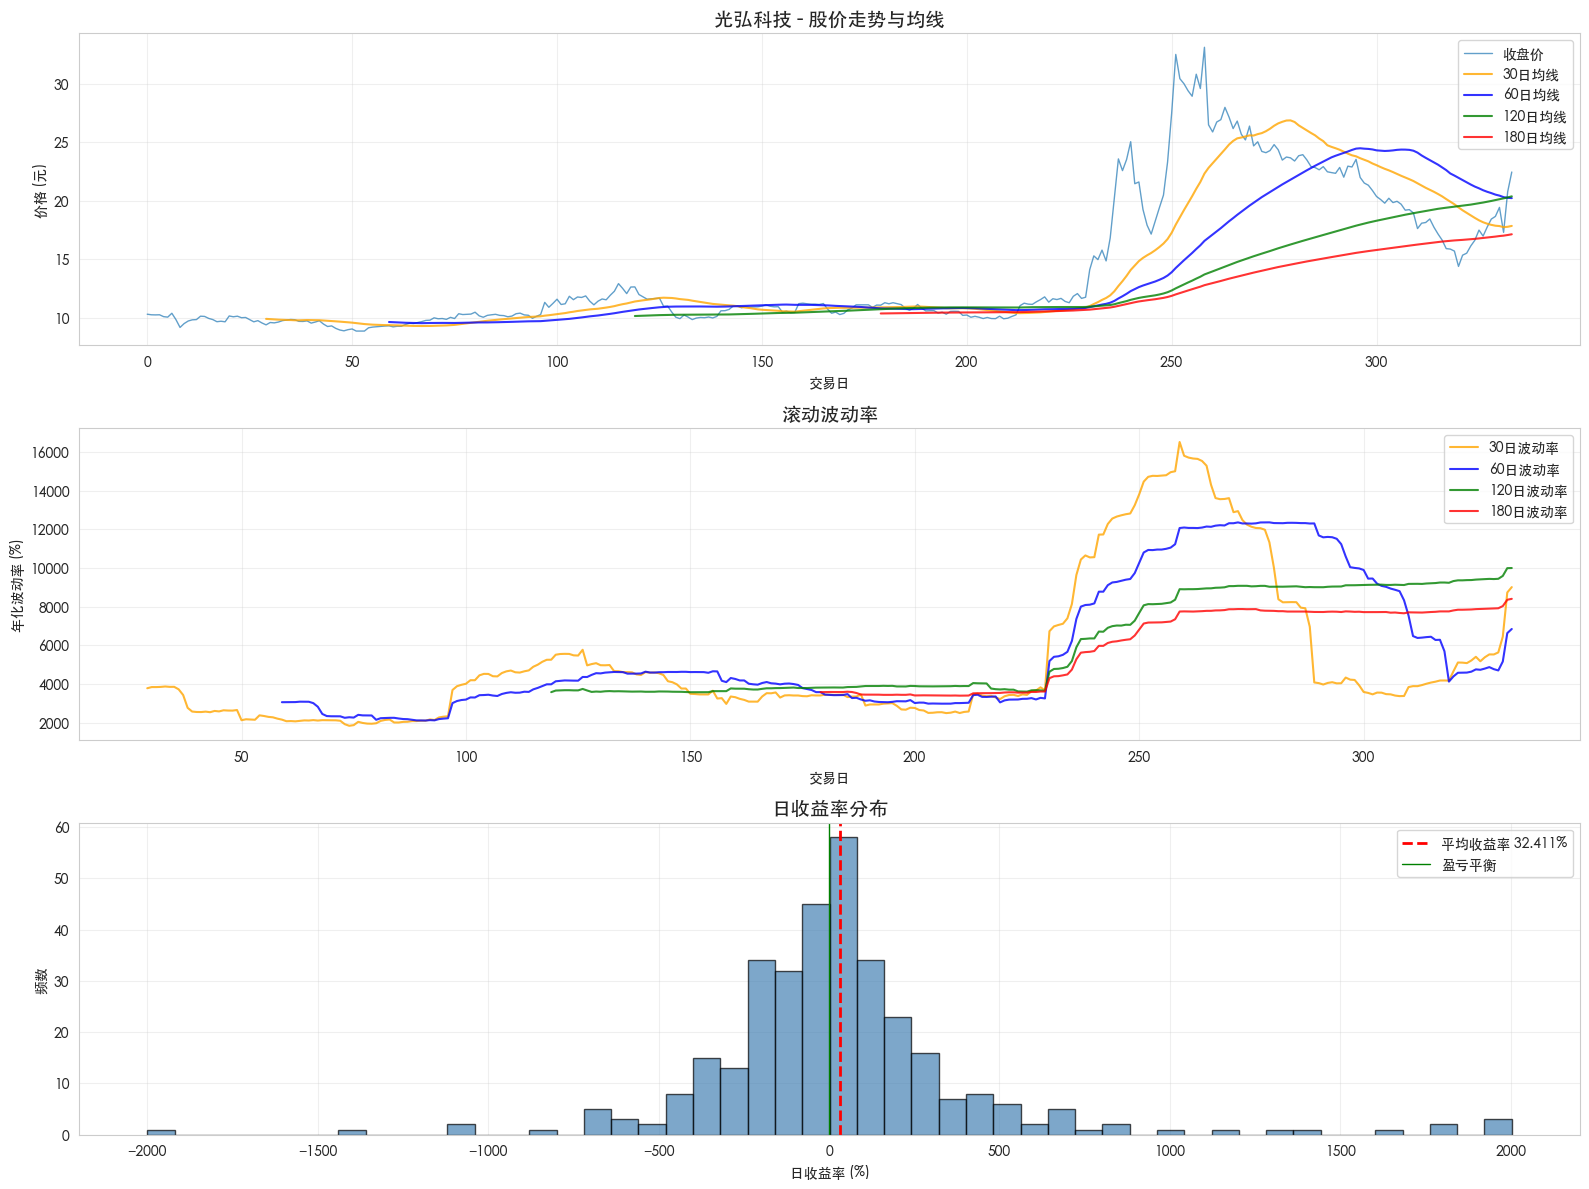

In [8]:
if not df_daily.empty:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    
    # 1. 股价走势与移动平均线
    ax1 = axes[0]
    ax1.plot(range(len(df_daily)), df_daily['close'], label='收盘价', linewidth=1, alpha=0.7)
    
    colors = ['orange', 'blue', 'green', 'red']
    for i, window in enumerate(HISTORY_PARAMS['windows']):
        ma_series = price_analysis[f'{window}日']['series']
        ax1.plot(range(len(df_daily)), ma_series, 
                label=f'{window}日均线', color=colors[i], linewidth=1.5, alpha=0.8)
    
    ax1.set_xlabel('交易日', fontproperties=font_prop)
    ax1.set_ylabel('价格 (元)', fontproperties=font_prop)
    ax1.set_title(f'{STOCK_CONFIG["name"]} - 股价走势与均线', 
                  fontproperties=font_prop, fontsize=14, fontweight='bold')
    ax1.legend(prop=font_prop)
    ax1.grid(True, alpha=0.3)
    for label in ax1.get_xticklabels():
        label.set_fontproperties(font_prop)
    for label in ax1.get_yticklabels():
        label.set_fontproperties(font_prop)
    
    # 2. 滚动波动率
    ax2 = axes[1]
    for i, window in enumerate(HISTORY_PARAMS['windows']):
        vol_series = volatility_analysis[f'{window}日']['series']
        ax2.plot(range(len(df_daily)), vol_series * 100, 
                label=f'{window}日波动率', color=colors[i], linewidth=1.5, alpha=0.8)
    
    ax2.set_xlabel('交易日', fontproperties=font_prop)
    ax2.set_ylabel('年化波动率 (%)', fontproperties=font_prop)
    ax2.set_title('滚动波动率', fontproperties=font_prop, fontsize=14, fontweight='bold')
    ax2.legend(prop=font_prop)
    ax2.grid(True, alpha=0.3)
    for label in ax2.get_xticklabels():
        label.set_fontproperties(font_prop)
    for label in ax2.get_yticklabels():
        label.set_fontproperties(font_prop)
    
    # 3. 日收益率分布
    ax3 = axes[2]
    ax3.hist(df_daily['pct_chg'] * 100, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax3.axvline(x=df_daily['pct_chg'].mean()*100, color='red', linestyle='--', 
               label=f'平均收益率 {df_daily["pct_chg"].mean()*100:.3f}%', linewidth=2)
    ax3.axvline(x=0, color='green', linestyle='-', label='盈亏平衡', linewidth=1)
    ax3.set_xlabel('日收益率 (%)', fontproperties=font_prop)
    ax3.set_ylabel('频数', fontproperties=font_prop)
    ax3.set_title('日收益率分布', fontproperties=font_prop, fontsize=14, fontweight='bold')
    ax3.legend(prop=font_prop)
    ax3.grid(True, alpha=0.3)
    for label in ax3.get_xticklabels():
        label.set_fontproperties(font_prop)
    for label in ax3.get_yticklabels():
        label.set_fontproperties(font_prop)
    
    plt.tight_layout()
    plt.show()

## 8. 导出数据供其他模块使用

In [ ]:
if not df_daily.empty:
    # 汇总所有分析结果
    market_data_summary = {
        # 基本信息
        'stock_code': STOCK_CONFIG['code'],
        'stock_name': STOCK_CONFIG['name'],
        'analysis_date': df_daily['trade_date'].iloc[-1],
        
        # 价格数据
        'current_price': float(df_daily['close'].iloc[-1]),
        'avg_price_all': float(basic_stats['平均收盘价']),
        'median_price': float(basic_stats['收盘价中位数']),
        'price_std': float(basic_stats['收盘价标准差']),
        
        # 波动率（使用60日作为推荐值）
        'volatility_30d': float(volatility_analysis['30日']['latest']),
        'volatility_60d': float(volatility_analysis['60日']['latest']),
        'volatility_120d': float(volatility_analysis['120日']['latest']),
        'volatility_180d': float(volatility_analysis['180日']['latest']),
        'volatility': float(volatility_analysis['60日']['latest']),  # 默认使用60日
        
        # 收益率（使用60日作为推荐值）
        'annual_return_30d': float(returns_analysis['30日']['annualized_return']),
        'annual_return_60d': float(returns_analysis['60日']['annualized_return']),
        'annual_return_120d': float(returns_analysis['120日']['annualized_return']),
        'annual_return_180d': float(returns_analysis['180日']['annualized_return']),
        'drift': float(returns_analysis['60日']['annualized_return']),  # 默认使用60日
        
        # 移动平均线
        'ma_30': float(price_analysis['30日']['latest_ma']),
        'ma_60': float(price_analysis['60日']['latest_ma']),
        'ma_120': float(price_analysis['120日']['latest_ma']),
        'ma_180': float(price_analysis['180日']['latest_ma']),
        
        # 其他统计
        'win_rate_60d': float(returns_analysis['60日']['win_rate']),
        'total_days': int(basic_stats['交易日数量']),
    }
    
    # 保存为JSON文件（统一保存到data目录）
    output_file = f"data/{STOCK_CONFIG['code'].replace('.', '_')}_market_data.json"
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(market_data_summary, f, indent=2, ensure_ascii=False)
    
    print('\n' + '='*70)
    print('✅ 市场数据分析完成')
    print('='*70)
    print(f"\n📊 关键指标汇总:")
    print(f"   当前价格: {market_data_summary['current_price']:.2f} 元")
    print(f"   推荐波动率(60日): {market_data_summary['volatility']*100:.2f}%")
    print(f"   推荐收益率(60日): {market_data_summary['drift']*100:.2f}%")
    print(f"\n💾 数据已保存到: {output_file}")
    print(f"\n📌 在其他notebook中使用:")
    print(f"   with open('{output_file}', 'r') as f:")
    print(f"       market_data = json.load(f)")
    print(f"   volatility = market_data['volatility']")
    print(f"   drift = market_data['drift']")

---

# 第二部分：板块指数分析

## 分析目标
基于主要市场指数的历史交易数据，计算真实的统计指标：
- 不同窗口的波动率（30/60/120/180日）
- 不同窗口的平均点位
- 历史收益率（年化）
- 价格统计特征
- 导出数据供情景分析使用

In [ ]:
# ============================================================
# 主要市场指数配置
# ============================================================

MARKET_INDICES = {
    '上证指数': {'code': '000001.SH', 'name': '上证指数'},
    '深证成指': {'code': '399001.SZ', 'name': '深证成指'},
    '沪深300': {'code': '000300.SH', 'name': '沪深300'},
    '中证500': {'code': '000905.SH', 'name': '中证500'},
    '创业板指': {'code': '399006.SZ', 'name': '创业板指'},
    '科创50': {'code': '000688.SH', 'name': '科创50'},
    '中证1000': {'code': '000852.SH', 'name': '中证1000'},
}

print('='*70)
print(f'📊 板块指数分析')
print(f'📈 分析指数数量: {len(MARKET_INDICES)} 个主要指数')
print('='*70)

In [ ]:
def fetch_index_data(index_code, lookback_days=500):
    """
    获取指数历史行情数据
    
    参数:
        index_code: 指数代码
        lookback_days: 回溯天数
    
    返回:
        DataFrame包含日期、收盘价、涨跌幅等
    """
    if pro is None:
        print("⚠️ Tushare API 未初始化，无法获取数据")
        return None
        
    end_date = datetime.now().strftime("%Y%m%d")
    start_date = (datetime.now() - timedelta(days=lookback_days)).strftime("%Y%m%d")
    
    try:
        df = pro.index_daily(ts_code=index_code, start_date=start_date, end_date=end_date)
        if df.empty:
            print(f"⚠️ {index_code} 无数据")
            return None
        
        # 按日期升序排列
        df = df.sort_values('trade_date').reset_index(drop=True)
        return df
    except Exception as e:
        print(f"❌ 获取 {index_code} 数据失败: {e}")
        return None


def analyze_single_index(index_name, index_config, params):
    """
    分析单个指数
    
    参数:
        index_name: 指数名称
        index_config: 指数配置（包含code和name）
        params: 分析参数
    
    返回:
        分析结果字典
    """
    print(f"\n{'='*70}")
    print(f"📊 分析: {index_name} ({index_config['code']})")
    print(f"{'='*70}")
    
    # 获取数据
    df = fetch_index_data(index_config['code'], params['lookback_days'])
    if df is None or df.empty:
        print(f"⚠️ {index_name} 无数据，跳过")
        return None
    
    # 计算波动率
    volatility_analysis = {}
    print(f"\n{'窗口':<10} {'最新波动率':<15} {'平均波动率':<15} {'中位数':<15}")
    print('-'*60)
    
    for window in params['windows']:
        vol_stats = calculate_rolling_volatility(df, window)
        volatility_analysis[f'{window}日'] = vol_stats
        
        print(f"{window}日{'':>5} {vol_stats['latest']*100:>7.2f}%       "
              f"{vol_stats['mean']*100:>7.2f}%       "
              f"{vol_stats['median']*100:>7.2f}%")
    
    # 计算收益率
    returns_analysis = {}
    print(f"\n{'窗口':<10} {'期间收益率':<20} {'年化收益率':<20} {'胜率':<15}")
    print('-'*65)
    
    for window in params['windows']:
        if len(df) < window:
            continue
        
        recent_df = df.iloc[-window:]
        
        # 期间收益率
        window_return = (recent_df['close'].iloc[-1] / recent_df['close'].iloc[0] - 1)
        
        # 年化收益率
        window_years = window / 252
        window_annualized = (1 + window_return) ** (1 / window_years) - 1
        
        # 胜率（上涨天数占比）
        win_rate = (recent_df['pct_chg'] > 0).sum() / len(recent_df)
        
        returns_analysis[f'{window}日'] = {
            'total_return': window_return,
            'annualized_return': window_annualized,
            'win_rate': win_rate
        }
        
        print(f"{window}日{'':>5} {window_return*100:>8.2f}%           "
              f"{window_annualized*100:>8.2f}%           "
              f"{win_rate*100:>8.1f}%")
    
    # 计算价格分析
    price_analysis = {}
    for window in params['windows']:
        if len(df) < window:
            continue
        
        rolling_mean = df['close'].rolling(window=window).mean()
        recent_prices = df['close'].iloc[-window:]
        
        price_analysis[f'{window}日'] = {
            'latest_ma': rolling_mean.iloc[-1],
            'recent_mean': recent_prices.mean(),
            'recent_max': recent_prices.max(),
            'recent_min': recent_prices.min(),
            'recent_std': recent_prices.std(),
        }
    
    # 汇总结果
    result = {
        'index_name': index_name,
        'index_code': index_config['code'],
        'data_start_date': df['trade_date'].iloc[0],
        'data_end_date': df['trade_date'].iloc[-1],
        'total_days': len(df),
        'current_close': float(df['close'].iloc[-1]),
        'volatility': volatility_analysis,
        'returns': returns_analysis,
        'price': price_analysis,
    }
    
    return result

print('✅ 指数分析函数定义完成')

In [ ]:
# 批量分析所有主要指数
all_indices_results = {}
for index_name, index_config in MARKET_INDICES.items():
    result = analyze_single_index(index_name, index_config, HISTORY_PARAMS)
    if result:
        all_indices_results[index_name] = result

print(f"\n{'='*70}")
print(f"✅ 市场指数分析完成")
print(f"{'='*70}")
print(f"\n📊 成功分析 {len(all_indices_results)} 个指数")

In [ ]:
# 创建对比表
comparison_data = []
for index_name, result in all_indices_results.items():
    comparison_data.append({
        '指数': index_name,
        '代码': result['index_code'],
        '当前点位': result['current_close'],
        '波动率(60日)': f"{result['volatility']['60日']['latest']*100:.2f}%",
        '年化收益(60日)': f"{result['returns']['60日']['annualized_return']*100:.2f}%",
        '胜率(60日)': f"{result['returns']['60日']['win_rate']*100:.1f}%",
        'MA60': f"{result['price']['60日']['latest_ma']:.2f}",
        '数据天数': result['total_days'],
    })

# 创建DataFrame
comparison_df = pd.DataFrame(comparison_data)
print("\n=== 主要市场指数对比分析 ===\n")
print(comparison_df.to_string(index=False))

# 显示DataFrame
comparison_df

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 提取数据用于绘图
index_names = list(all_indices_results.keys())
volatilities_60d = [all_indices_results[name]['volatility']['60日']['latest']*100
                     for name in index_names]
returns_60d = [all_indices_results[name]['returns']['60日']['annualized_return']*100
               for name in index_names]
win_rates_60d = [all_indices_results[name]['returns']['60日']['win_rate']*100
                  for name in index_names]

# 1. 波动率对比
ax1 = axes[0, 0]
colors1 = plt.cm.Reds(np.linspace(0.3, 0.9, len(index_names)))
bars1 = ax1.barh(index_names, volatilities_60d, color=colors1, alpha=0.8)
ax1.set_xlabel('年化波动率 (%)', fontproperties=font_prop, fontsize=12)
ax1.set_title('各指数波动率对比 (60日窗口)', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
for i, (bar, vol) in enumerate(zip(bars1, volatilities_60d)):
    ax1.text(vol + 0.5, i, f'{vol:.1f}%', va='center', fontsize=10)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)

# 2. 年化收益率对比
ax2 = axes[0, 1]
colors2 = ['green' if r > 0 else 'red' for r in returns_60d]
bars2 = ax2.barh(index_names, returns_60d, color=colors2, alpha=0.8)
ax2.set_xlabel('年化收益率 (%)', fontproperties=font_prop, fontsize=12)
ax2.set_title('各指数年化收益率对比 (60日窗口)', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.grid(True, alpha=0.3, axis='x')
for i, (bar, ret) in enumerate(zip(bars2, returns_60d)):
    ax2.text(ret + (1 if ret > 0 else -1), i, f'{ret:.1f}%',
             va='center', ha='left' if ret > 0 else 'right', fontsize=10)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)

# 3. 胜率对比
ax3 = axes[1, 0]
colors3 = plt.cm.Blues(np.linspace(0.3, 0.9, len(index_names)))
bars3 = ax3.barh(index_names, win_rates_60d, color=colors3, alpha=0.8)
ax3.set_xlabel('胜率 (%)', fontproperties=font_prop, fontsize=12)
ax3.set_title('各指数胜率对比 (60日窗口)', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax3.set_xlim(0, 100)
ax3.grid(True, alpha=0.3, axis='x')
for i, (bar, wr) in enumerate(zip(bars3, win_rates_60d)):
    ax3.text(wr + 1, i, f'{wr:.1f}%', va='center', fontsize=10)
for label in ax3.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax3.get_xticklabels():
    label.set_fontproperties(font_prop)

# 4. 当前点位对比（标准化）
ax4 = axes[1, 1]
ma_distances = [(all_indices_results[name]['current_close'] /
                all_indices_results[name]['price']['60日']['latest_ma'] - 1) * 100
               for name in index_names]
colors4 = ['green' if d > 0 else 'red' for d in ma_distances]
bars4 = ax4.barh(index_names, ma_distances, color=colors4, alpha=0.8)
ax4.set_xlabel('相对MA60的偏离 (%)', fontproperties=font_prop, fontsize=12)
ax4.set_title('各指数技术位置对比', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.grid(True, alpha=0.3, axis='x')
for i, (bar, dist) in enumerate(zip(bars4, ma_distances)):
    ax4.text(dist + (0.5 if dist > 0 else -0.5), i, f'{dist:+.1f}%',
             va='center', ha='left' if dist > 0 else 'right', fontsize=10)
for label in ax4.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax4.get_xticklabels():
    label.set_fontproperties(font_prop)

plt.tight_layout()
plt.show()

In [ ]:
# 导出指数数据（使用统一的数据模块）
from utils.market_data_loader import save_market_indices_data

# 调用统一的数据导出函数（保存到data目录）
save_market_indices_data(all_indices_results, data_dir='data')

print('\n' + '='*70)
print('✅ 指数数据分析完成')
print('='*70)
print(f"\n📊 分析指数数量: {len(all_indices_results)}")
print(f"\n💾 数据已通过market_data_loader模块保存到data目录")
print(f"\n📌 在其他模块中使用:")
print(f"   from utils.market_data_loader import load_market_indices_data, get_index_risk_params")
print(f"   indices_data = load_market_indices_data(data_dir='data')")
print(f"   risk_params = get_index_risk_params(indices_data, '沪深300')")
print(f"   volatility = risk_params['volatility']")
print(f"   drift = risk_params['drift']")
print(f"\n📊 可用指数:")
for name in all_indices_results.keys():
    print(f"   - {name}")